In [1]:
import os
%load_ext autoreload
%autoreload 2

In [2]:
# Cell 1: Imports (Make sure these are at the top of your notebook)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader
import gc
import os
import sys

from preprocessing.preprocessing import preprocess_lob_data, split_data_chronological, normalize_features
from preprocessing.dataset import create_sequences, LOBSequenceDataset

from training.trainer import Trainer, Config
from utils.utils import print_model_info

In [3]:
print(os.getcwd())

/Users/janyubhatt/Documents/Learning/Courses/OMSCS/crytpo_DLOB/notebooks


In [4]:
os.chdir('..')  # only need this temporily to get the right paths, change as needed
print(os.getcwd())

/Users/janyubhatt/Documents/Learning/Courses/OMSCS/crytpo_DLOB


In [37]:
import yaml
with open("configs/test_runner.cfg", "r") as f:
    config_dict = yaml.safe_load(f)
config = Config(config_dict)

In [6]:
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [7]:
config.num_files

1

In [8]:
# --- 1. Preprocess Data ---
df_processed = preprocess_lob_data(config)
gc.collect()

Memory Usage: 228.70 MB
Shape before cleaning (dropna): (731123, 81)
NaN count before: 0
Shape after cleaning: (731123, 81)
NaN count after: 0
Calculating alpha dynamically...
Dynamic alpha = 0.000070
Shape after label creation and NaN drop: (731023, 12)
Label distribution:
label
1    0.432018
2    0.284556
0    0.283426
Name: proportion, dtype: float64


0

In [9]:
display(df_processed.shape)
df_processed.head()

(731023, 12)

,b0,b1,a0,a1,bq0,bq1,aq0,aq1,mid_price,spread,vol_imbalance_2,label
50,67828.171875,67826.640625,67828.179688,67830.312500,0.099000,0.041000,0.082174,0.015000,67828.171875,0.007812,0.180569,2
51,67835.062500,67834.437500,67836.000000,67838.031250,0.119232,0.041000,0.022174,0.036852,67835.531250,0.937500,0.461580,2
52,67835.062500,67834.437500,67835.937500,67835.953125,0.117270,0.041000,0.022173,0.150019,67835.500000,0.875000,-0.042129,2
53,67834.437500,67828.187500,67834.453125,67834.468750,0.109949,0.018934,0.430301,0.123337,67834.445312,0.015625,-0.622330,2
54,67828.367188,67828.359375,67832.156250,67833.101562,0.003000,0.010000,0.000856,0.003034,67830.265625,3.789062,0.539332,2


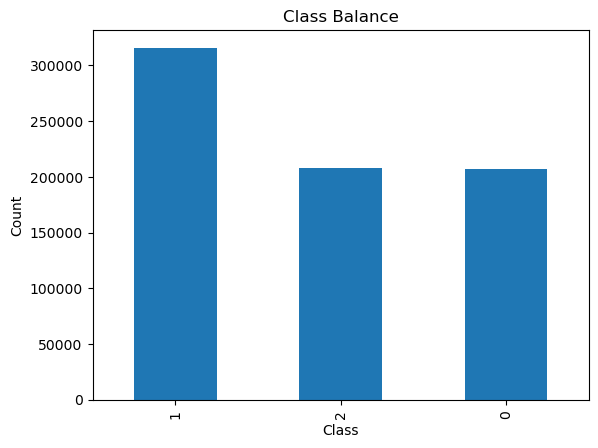

In [10]:
import matplotlib.pyplot as plt
class_counts = df_processed['label'].value_counts()
# Plot
class_counts.plot(kind='bar')
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [11]:
# --- 2. Split Data ---
train_df, val_df, test_df = split_data_chronological(
    df_processed,
    train_frac=config_dict['split_fractions']['train'],
    val_frac=config_dict['split_fractions']['val'],
    test_frac=config_dict['split_fractions']['test']
)
del df_processed
gc.collect()

Data Split: Train=511716, Val=109653, Test=109654


3019

In [12]:
train_df.dtypes.unique(), val_df.dtypes.unique(), test_df.dtypes.unique(),

(array([dtype('float32'), dtype('int64')], dtype=object),
 array([dtype('float32'), dtype('int64')], dtype=object),
 array([dtype('float32'), dtype('int64')], dtype=object))

In [13]:
train_df.head()

,b0,b1,a0,a1,bq0,bq1,aq0,aq1,mid_price,spread,vol_imbalance_2,label
50,67828.171875,67826.640625,67828.179688,67830.312500,0.099000,0.041000,0.082174,0.015000,67828.171875,0.007812,0.180569,2
51,67835.062500,67834.437500,67836.000000,67838.031250,0.119232,0.041000,0.022174,0.036852,67835.531250,0.937500,0.461580,2
52,67835.062500,67834.437500,67835.937500,67835.953125,0.117270,0.041000,0.022173,0.150019,67835.500000,0.875000,-0.042129,2
53,67834.437500,67828.187500,67834.453125,67834.468750,0.109949,0.018934,0.430301,0.123337,67834.445312,0.015625,-0.622330,2
54,67828.367188,67828.359375,67832.156250,67833.101562,0.003000,0.010000,0.000856,0.003034,67830.265625,3.789062,0.539332,2


In [14]:
# --- 3. Normalize Features ---

# Select ONLY numeric feature columns for scaling
# Exclude the 'label' column as well
numeric_cols = train_df.select_dtypes(include=np.number).columns
feature_cols = [col for col in numeric_cols if col != 'label']

# Optional: Print to verify which columns are being scaled
print(f"Columns selected for scaling ({len(feature_cols)}): {feature_cols[:10]}...") # Print first 10

# Check if feature_cols is empty
if not feature_cols:
    raise ValueError("No numerical feature columns found for scaling after excluding 'label'.")

# Call normalize_features with the correctly filtered list
train_df_norm, val_df_norm, test_df_norm, scaler = normalize_features(
    train_df, val_df, test_df, feature_cols
)
train_df_norm.loc[:, "label"] = train_df.loc[:, "label"].copy()
val_df_norm.loc[:, "label"] = val_df.loc[:, "label"].copy()
test_df_norm.loc[:, "label"] = test_df.loc[:, "label"].copy()
del train_df, val_df, test_df
gc.collect()


Columns selected for scaling (11): ['b0', 'b1', 'a0', 'a1', 'bq0', 'bq1', 'aq0', 'aq1', 'mid_price', 'spread']...
Normalization applied.


0

In [15]:
train_df_norm.head()

,b0,b1,a0,a1,bq0,bq1,aq0,aq1,mid_price,spread,vol_imbalance_2,label
50,-1.696550,-1.718980,-1.901067,-1.899762,0.019889,-0.402048,-0.035210,-0.046485,-1.818930,0.370141,0.078368,2
51,-1.686842,-1.707769,-1.887615,-1.886485,0.076638,-0.402048,-0.055029,-0.030291,-1.807337,0.373616,0.473201,2
52,-1.686842,-1.707769,-1.887723,-1.890060,0.071133,-0.402048,-0.055030,0.053569,-1.807386,0.373383,-0.234534,2
53,-1.687722,-1.716756,-1.890276,-1.892613,0.050601,-0.419456,0.079783,0.033797,-1.809047,0.370170,-1.049743,2
54,-1.696275,-1.716508,-1.894227,-1.894964,-0.249379,-0.426504,-0.062071,-0.055352,-1.815632,0.384277,0.582447,2


In [16]:
config.sequence_length = 1

In [17]:
if config.precision == 'float16' or None:
    precision = np.float16
elif config.precision == 'float32':
    precision = np.float32
elif config.precision == 'float64':
    precision = np.float64

print(f"Precision is: {precision}")

Precision is: <class 'numpy.float32'>


In [ ]:
# --- 4. Create Sequences ---
# Separate features and labels before sequencing
y_train_series = train_df_norm.pop('label').values
X_train_features = train_df_norm[feature_cols].astype(np.float16).values

y_val_series = val_df_norm.pop('label').values
X_val_features = val_df_norm[feature_cols].astype(np.float16).values

y_test_series = test_df_norm.pop('label').values
X_test_features = test_df_norm[feature_cols].astype(np.float16).values

T = config.sequence_length
X_train_seq, y_train_seq = create_sequences(X_train_features, y_train_series, T, precision=np.float16)
X_val_seq, y_val_seq = create_sequences(X_val_features, y_val_series, T, precision=np.float16)
X_test_seq, y_test_seq = create_sequences(X_test_features, y_test_series, T, precision=np.float16)

print("\nSequence Creation Complete:")
print(f"X_train_seq shape: {X_train_seq.shape}, y_train_seq shape: {y_train_seq.shape}")
print(f"X_val_seq shape: {X_val_seq.shape}, y_val_seq shape: {y_val_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}, y_test_seq shape: {y_test_seq.shape}")

del train_df_norm, val_df_norm, test_df_norm # Free memory
del X_train_features, y_train_series, X_val_features, y_val_series, X_test_features, y_test_series
gc.collect()

In [ ]:
# --- 5. Create Datasets & DataLoaders ---
train_dataset = LOBSequenceDataset(X_train_seq, y_train_seq, device=device)
val_dataset = LOBSequenceDataset(X_val_seq, y_val_seq, device=device)
test_dataset = LOBSequenceDataset(X_test_seq, y_test_seq, device=device)

#train_loader = DataLoader(train_dataset, batch_size=config.train.batch_size, shuffle=True) # num_workers/pin_memory optional
#val_loader = DataLoader(val_dataset, batch_size=config.train.batch_size, shuffle=False)
#test_loader = DataLoader(test_dataset, batch_size=config.train.batch_size, shuffle=False)
# gc.collect()

In [20]:
config.model.in_features = config.num_levels_features * 4 + 3

In [39]:
trainer = Trainer(config, train_dataset, val_dataset, test_dataset, device)

One batch shape: torch.Size([1024, 11, 1])

Datasets and DataLoaders created.
Number of training batches: 500
Number of validation batches: 108
Number of testing batches: 108
Input Size: (1, 11)
Model: Basic MLP Model

📋 Model Summary:

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
BasicMLPModel                            [1, 11]                   [1, 3]                    36                        --
├─Linear: 1-1                            [1, 11]                   [1, 3]                    36                        --
├─ReLU: 1-2                              [1, 3]                    [1, 3]                    --                        --
Total params: 72
Trainable params: 72
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


In [40]:
trainer.device

'mps'

In [41]:
trainer.train()

Starting Training
Epochs: 2 | Num Batches: 500
Epoch[Batch]: [1][0/500]	Avg_Loss 1.105 (1.105)	 Time 0.123 (0.123)	
Epoch[Batch]: [1][50/500]	Avg_Loss 1.090 (1.086)	 Time 0.011 (0.013)	


KeyboardInterrupt: 

TypeError: no numeric data to plot

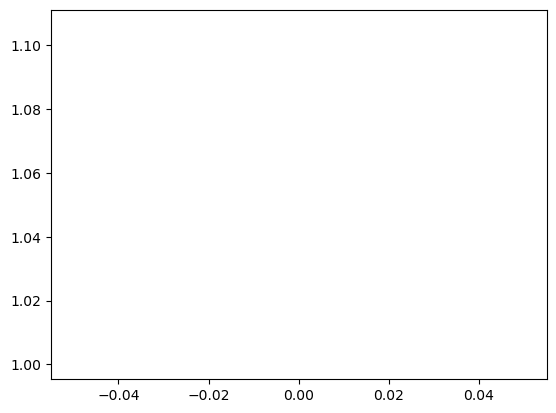

In [26]:
pd.Series(trainer.train_loss).plot(label="Train loss vs epoch")
pd.Series(trainer.val_loss).plot(label="validation loss vs epoch")
plt.title("Loss Curve Vs Epoch")
plt.legend()
plt.show()

In [28]:
trainer.val_loss 

[(1.1265907422840384, array(0.17756389, dtype=float32))]